### Exercise 0: Create the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

dates = pd.date_range(
    start="2018-01-01",
    end="2025-12-01",
    freq="MS"
)
n = len(dates)
trend = np.linspace(100, 250, n)
seasonal_pattern = np.array([
    0.80, 0.85, 0.90, 0.95,
    1.00, 1.05, 1.10, 1.05,
    1.00, 1.10, 1.25, 1.50
])
seasonality = np.tile(seasonal_pattern, n // 12)
noise = np.random.normal(0, 8, n)
sales = trend * seasonality + noise
customers = (
    sales * 4
    + np.random.normal(0, 30, n)
)
promotion = np.random.choice(
    [0, 1],
    size=n,
    p=[0.7, 0.3]
)
sales = sales + promotion * 15
df = pd.DataFrame({
    "date": dates,
    "sales": sales,
    "customers": customers,
    "promotion": promotion
})
df.head()

,date,sales,customers,promotion
0,2018-01-01,83.973713,344.778461,0
1,2018-02-01,85.235991,348.775622,0
2,2018-03-01,113.023614,392.247858,1
3,2018-04-01,111.684239,439.699341,0
4,2018-05-01,104.442562,375.309128,0


In [2]:
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)
df.head()

,sales,customers,promotion
date,,,
2018-01-01,83.973713,344.778461,0
2018-02-01,85.235991,348.775622,0
2018-03-01,113.023614,392.247858,1
2018-04-01,111.684239,439.699341,0
2018-05-01,104.442562,375.309128,0


1. 96 observations

2. Frequency: Monthly

3. Variables available:
    * date — the month/date
    * sales — sales value
    * customers — number of customers
    * promotion — promotion indicator

4. Promotion variable: A binary variable indicating whether a promotion was active that month:

   * 0 = no promotion 
   * 1 = promotion 

### Part 1: Visualizing the Time Series

#### Exercise 2: Plot Monthly Sales

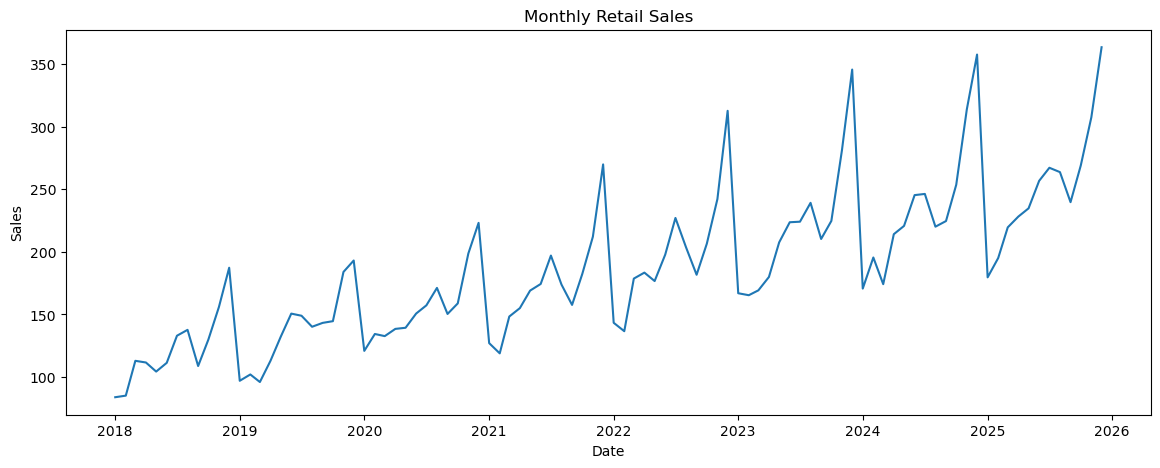

In [3]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["sales"])
plt.title("Monthly Retail Sales")
plt.xlabel("Date")
plt.ylabel("Sales");

1. yes 
2. yes 
3. on some cases some seasons unusally appears to be high or low 
4. it appears to increase(multiplicative)
5. summer(oct, nov)

### Part 2: Moving Average

#### Exercise 3: Calculate a 3-Month Moving Average

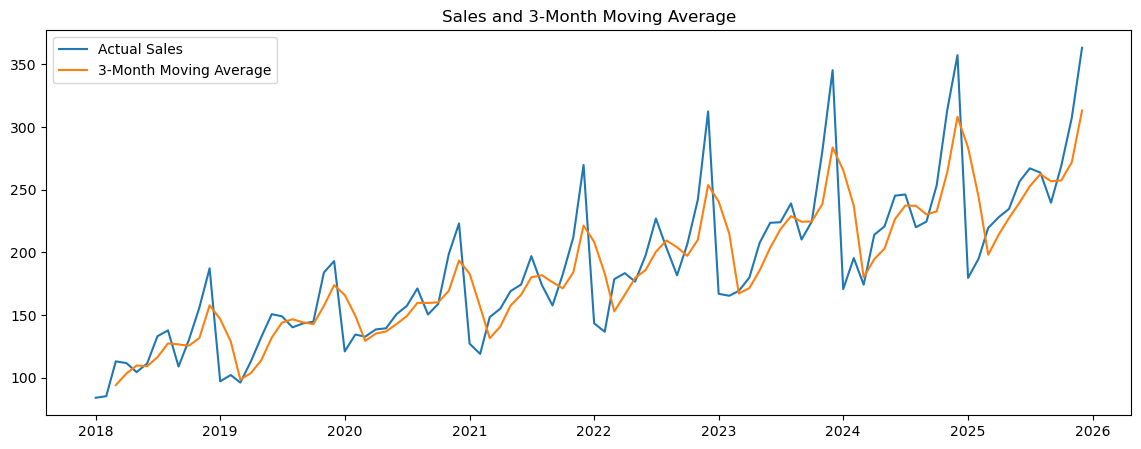

In [4]:
df["MA_3"] = df["sales"].rolling(window=3).mean()
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["sales"], label="Actual Sales")
plt.plot(df.index, df["MA_3"], label="3-Month Moving Average")
plt.legend()
plt.title("Sales and 3-Month Moving Average");

1. It smooths the sales series by averaging nearby values.
2. Yes, it is smoother than the original series.
3. The first 2 observations are missing because a 3-month average needs 3 values.
4. Yes, it reduces some random noise.
5. No, seasonality remains, though it is somewhat reduced.

#### Exercise 4: Compare Different Moving Averages

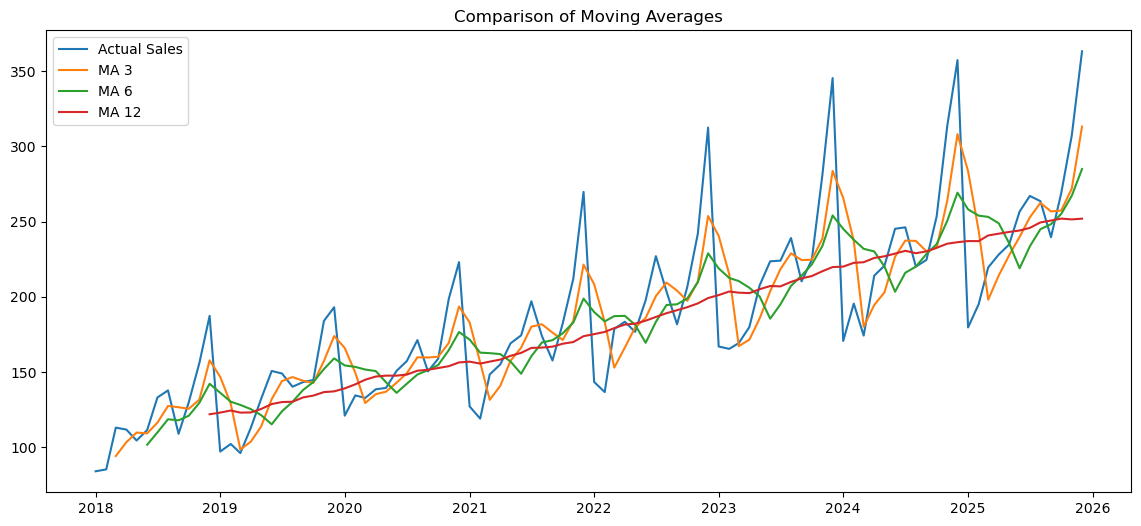

In [5]:
df["MA_3"] = df["sales"].rolling(3).mean()
df["MA_6"] = df["sales"].rolling(6).mean()
df["MA_12"] = df["sales"].rolling(12).mean()
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["sales"], label="Actual Sales")
plt.plot(df.index, df["MA_3"], label="MA 3")
plt.plot(df.index, df["MA_6"], label="MA 6")
plt.plot(df.index, df["MA_12"], label="MA 12")
plt.legend()
plt.title("Comparison of Moving Averages");

1. MA 3 reacts fastest to recent changes. because it averages only 3 months of data. When a new sales value appears, it has a large influence on the average.
2. MA 12 — averages the most data points.
3. MA 12.
4. MA 12, because it filters out seasonal and short-term fluctuations more effectively.
5. Small windows respond quickly but are more noisy; large windows are smoother and better for trends but react more slowly to changes.

### Part 3: Additive and Multiplicative Decomposition

#### Exercise 5: Additive Decomposition

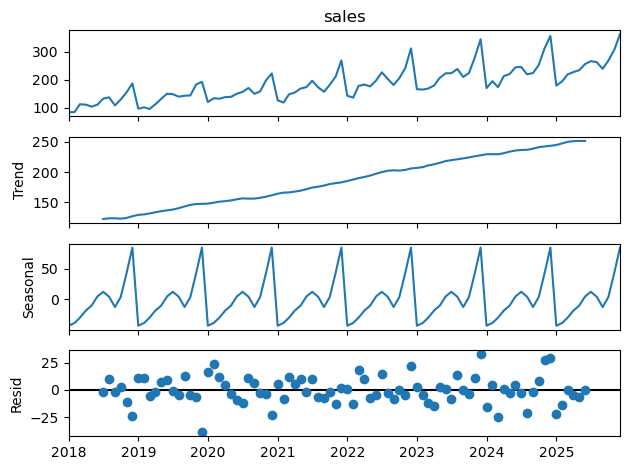

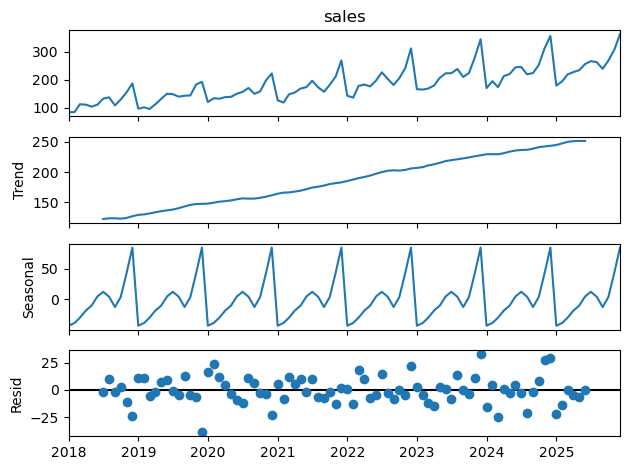

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
additive = seasonal_decompose(
    df["sales"],
    model="additive",
    period=12
)
additive.plot()

1. Sales show an overall upward trend from 2018 to 2025.
2. Sales are generally lower at the beginning of the year and higher toward the end, especially November and December.
3. No. The seasonal effect increases somewhat as the overall sales level rises.
4. The residual represents random/unexplained variation after removing the trend and seasonality.
5. Mainly Oct, Nov, and early Dec.
6. Mainly Jan–Mar, 

#### Exercise 6: Multiplicative Decomposition

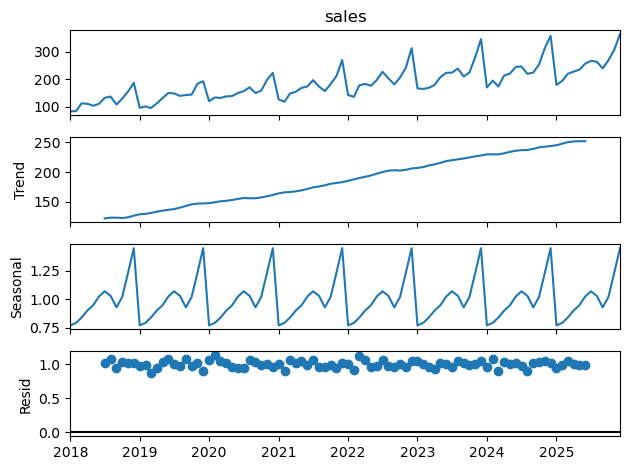

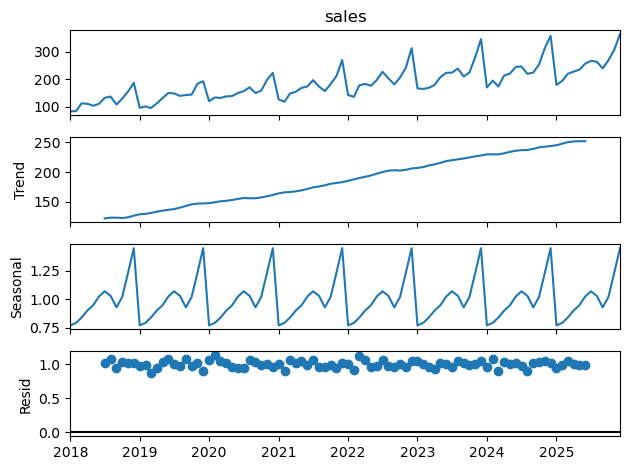

In [7]:
multiplicative = seasonal_decompose(
    df["sales"],
    model="multiplicative",
    period=12
)
multiplicative.plot()

1. Additive assumes Sales = Trend + Seasonality + Residual; multiplicative assumes Sales = Trend × Seasonality × Residual.
2. Yes, the seasonal swings become larger as sales rise.
3. Yes, approximately.
4. Yes. It appears more appropriate because the seasonal effect grows with the overall sales level.

#### Exercise 7: Additive vs Multiplicative Comparison

| Characteristic                           | Additive                       | Multiplicative                 |
| ---------------------------------------- | ------------------------------ | ------------------------------ |
| **Basic relationship**                   | Trend + Seasonality + Residual | Trend × Seasonality × Residual |
| **Seasonal effect**                      | Constant amount                | Proportional/percentage        |
| **Seasonal variation constant?**         | Yes, approximately             | No                             |
| **Seasonal variation grows with level?** | No                             | Yes                            |
| **Example**                              | 100 + 20 = 120                 | 100 × 1.20 = 120               |


1. additive? When seasonal fluctuations are roughly constant in size.
2. multiplicative? When seasonal fluctuations increase as the series level increases.
3. diferenciating this helps with
    * Interpretation:
    Additive → “December adds about 20 sales.”
    Multiplicative → “December increases sales by about 20%.”
    * Business decisions: Helps you understand whether seasonal demand is a fixed amount or a percentage of current sales

### Part 4: Stationarity

#### Exercise 8: Visual Stationarity Assessment

1. No, it increases over time.
2. No, variation becomes larger as sales increase.
3. Yes, there is a clear upward trend.
4. Yes, there is a repeating yearly pattern.
5. Non-stationary.
6. The graph shows a changing mean, increasing variation, and clear trend and seasonality. These mean the statistical properties are not stable over time.

#### Exercise 9: Compare Different Periods

In [8]:
first = df["sales"].iloc[:24]
middle = df["sales"].iloc[24:48]
last = df["sales"].iloc[-24:]

print("First period mean:", first.mean())
print("Middle period mean:", middle.mean())
print("Last period mean:", last.mean())

print("First period std:", first.std())
print("Middle period std:", middle.std())
print("Last period std:", last.std())

First period mean: 129.50749024391905
Middle period mean: 165.09152388690129
Last period mean: 244.1476883717368
First period std: 30.713317552398202
Middle period std: 35.52279961514827
Last period std: 51.18185662970535


1. No, it increases from about 129.5 to 244.1.
2. No, it increases from about 30.7 to 51.2.
3. The series is non-stationary because its mean and variability change over time.
4. A graph may not clearly reveal subtle changes especially when there is a lot of data to observe. Statistical tests can provide more objective evidence.

### Part 5: Augmented Dickey-Fuller (ADF) Test

#### Exercise 10: Perform the ADF Test

In [9]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["sales"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

for key, value in result[4].items():
    print(f"Critical Value ({key}): {value}")

ADF Statistic: 0.03202228163186219
p-value: 0.9611015371515225
Critical Value (1%): -3.510711795769895
Critical Value (5%): -2.8966159448223734
Critical Value (10%): -2.5854823866213152


1. ADF statistic: 0.0320
2. p-value: 0.9611
3. Null hypothesis (H₀): The series has a unit root, meaning it is non-stationary.
4. Decision: Fail to reject H₀ because p-value > 0.05.
5. non-stationary.

#### Exercise 11: Interpret ADF Results

1. NO
2. NO
3. NO
4. use log function tthen differenciate it 

### Part 6: Differencing

#### Exercise 12: First-Order Differencing

Text(0, 0.5, 'Difference')

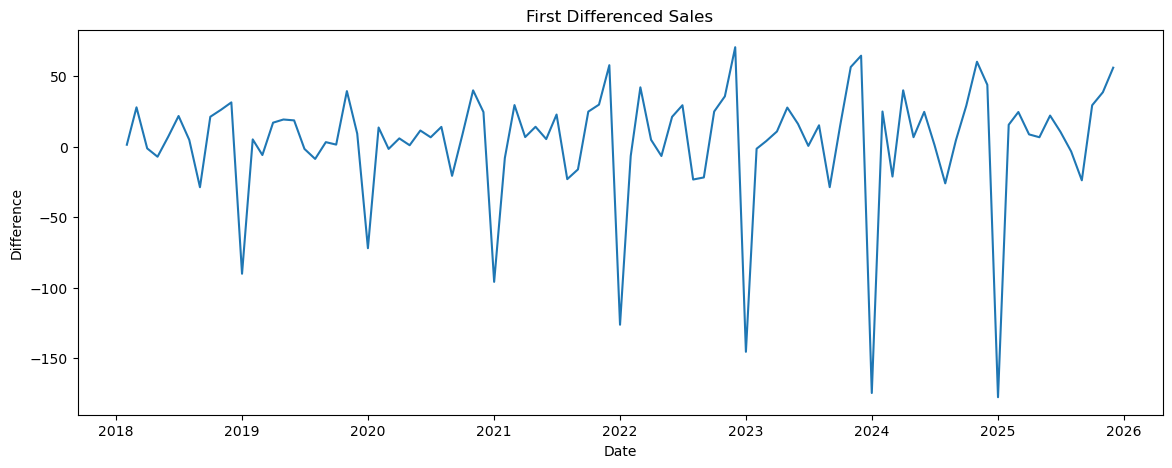

In [10]:
df["sales_diff"] = df["sales"].diff()
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["sales_diff"])
plt.title("First Differenced Sales")
plt.xlabel("Date")
plt.ylabel("Difference")

1. Yes, it removes much of the upward trend.
2. Yes, it is generally more stable around zero.
3. It became NaN (missing).
4. Differencing needs a previous value: Difference = Current − Previous. The first value has no previous observation.
5. Yes, some yearly seasonal pattern may still remain.

#### Exercise 13: ADF Test After Differencing

In [11]:
result_diff = adfuller(df["sales_diff"].dropna())
print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])
for key, value in result_diff[4].items():
    print(f"Critical Value ({key}): {value}")

ADF Statistic: -22.788748410220517
p-value: 0.0
Critical Value (1%): -3.510711795769895
Critical Value (5%): -2.8966159448223734
Critical Value (10%): -2.5854823866213152


1. Yes. It dropped from 0.9611 to 0.0.
2. Yes, because p-value < 0.05.
3. 1 difference.
4. d = 1.

### Part 7: Autocorrelation Function (ACF)

#### Exercise 14: Plot ACF

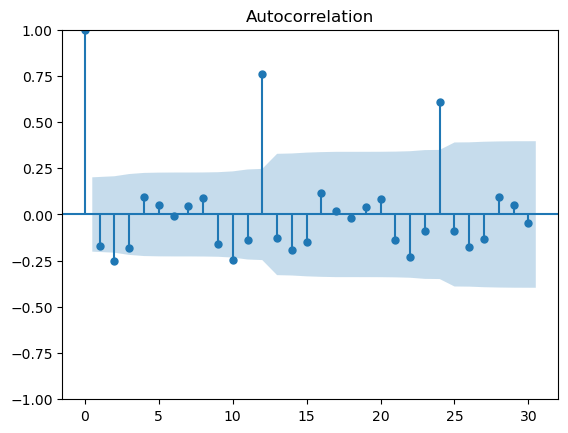

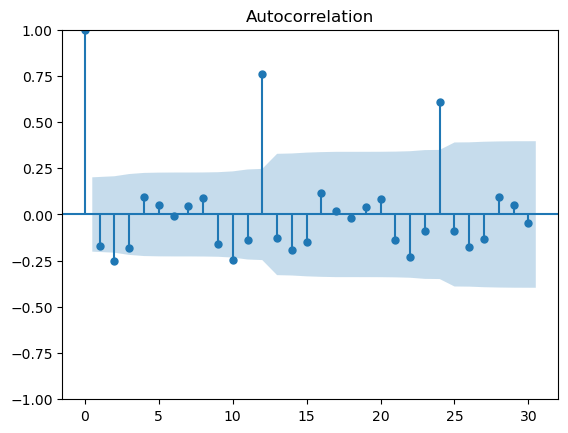

In [12]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(
    df["sales_diff"].dropna(),
    lags=30
)

1. Correlation between a value and the value 1 month earlier.
2. Correlation with the value 2 months earlier.
3. Correlation with the value 12 months earlier — important for yearly seasonality.
4. Lags whose spikes extend outside the blue confidence bands.
5. If lag 12 is significant, there is evidence of yearly seasonal autocorrelation.
6. If correlations gradually decrease toward zero, the ACF tails off gradually; if they suddenly become insignificant, it cuts off quickly.

### Part 8: Partial Autocorrelation Function (PACF)

#### Exercise 15: Plot PACF

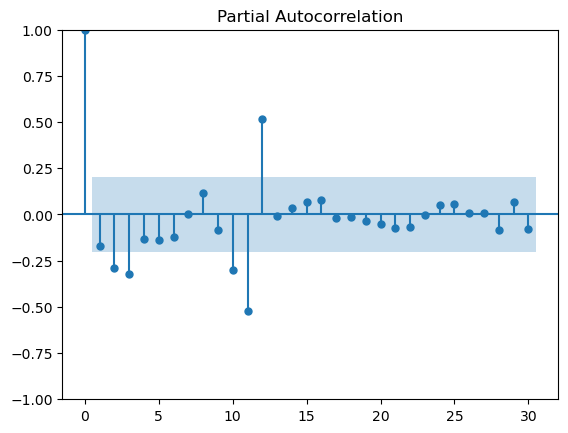

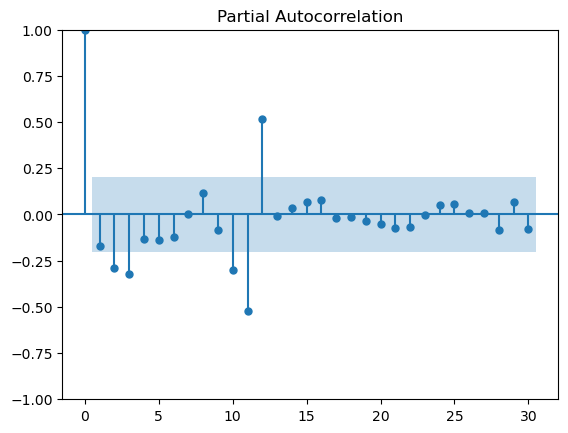

In [13]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(
    df["sales_diff"].dropna(),
    lags=30,
    method="ywm")

1. Mainly lag 1 (and any other spikes outside the confidence bands).
2. Yes, mostly after the first lag.
3. Not strongly; it drops off relatively quickly.
4. p = 1.
5. Possibly, if lag 12 is outside the confidence bands; check the plot.

### Part 9: ARIMA Models

#### Exercise 16: Train-Test Split

In [14]:
train = df["sales"].iloc[:-12]
test = df["sales"].iloc[-12:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 84
Testing observations: 12


1. To evaluate how well the model predicts unseen data.
2. It would mix future data with past data, causing data leakage.
3. They represent the future the model would actually need to predict, giving a realistic test of forecasting performance.

#### Exercise 17: Build Your First ARIMA Mode

In [15]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(
    train,
    order=(1, 1, 1)
)
model_fit = model.fit()
print(model_fit.summary())

C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA param

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                   84
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -417.437
Date:                Wed, 19 Aug 2026   AIC                            840.874
Time:                        14:38:25   BIC                            848.130
Sample:                    01-01-2018   HQIC                           843.789
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3822      0.266      1.436      0.151      -0.139       0.904
ma.L1         -0.8561      0.170     -5.038      0.000      -1.189      -0.523
sigma2      1356.3031    167.471      8.099      0.0

1. p = 1: Uses 1 previous value (AR term).
2. d = 1: Takes 1 difference to make the series stationary.
3. q = 1: Uses 1 previous forecast error (MA term).
4. The original sales were non-stationary, but became stationary after one difference.
5. How did ACF/PACF help?
    * PACF → p: suggested p = 1 because lag 1 was significant.
    * ACF → q: suggested q = 1 based on the early significant autocorrelation.

#### Exercise 18: Forecast the Test Period

2025-01-01    302.140859
2025-02-01    281.008797
2025-03-01    272.932319
2025-04-01    269.845564
2025-05-01    268.665835
2025-06-01    268.214953
2025-07-01    268.042630
2025-08-01    267.976770
2025-09-01    267.951599
2025-10-01    267.941979
2025-11-01    267.938302
2025-12-01    267.936897
Freq: MS, Name: predicted_mean, dtype: float64


Text(0.5, 1.0, 'ARIMA Forecast')

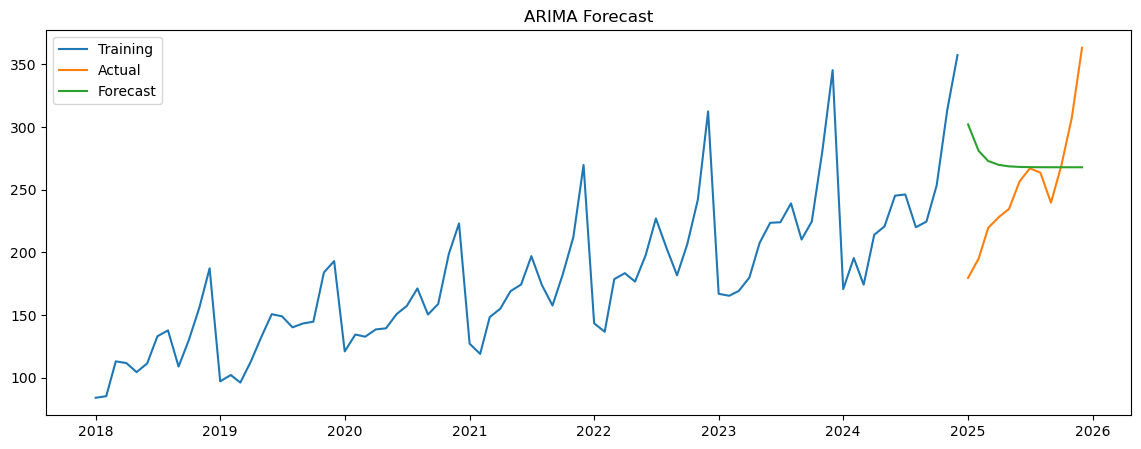

In [16]:
forecast = model_fit.forecast(steps=12)
print(forecast)
plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label="Training")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast")

1. Yes, the forecast should follow the overall upward direction of actual sales.
2. Not very well; basic ARIMA(1,1,1) does not explicitly model the 12-month seasonality.
3. Likely during strong seasonal peaks, especially high-sales months.
4. Seasonality and changing seasonal effects, because the model is non-seasonal.

### Part 10: ARIMA Evaluation

#### Exercise 19: Calculate MAE and RMSE

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae = mean_absolute_error(test, forecast)
print("MAE:", mae)
rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE:", rmse)

MAE: 43.20481332762963
RMSE: 57.54898339143721


1. Measures the average absolute error between actual and forecast values.
2. Measures the square root of the average squared errors.
3. RMSE, because errors are squared.
4. Lower MAE.
5. Lower RMSE.

### Part 11: SARIMA Models

#### Exercise 20: Build a SARIMA Model

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)
model_fit = model.fit(disp=False)
print(model_fit.summary())

C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                   84
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -290.562
Date:                            Wed, 19 Aug 2026   AIC                            591.124
Time:                                    14:38:27   BIC                            602.437
Sample:                                01-01-2018   HQIC                           595.623
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0645      0.159      0.406      0.685      -0.247       0.376
ma.L1         -0.9860      0.121   

1. Non-seasonal (p,d,q):
   * p=1: 1 AR term
   * d=1: 1 difference
   * q=1: 1 MA term
2. (1,1,1,12) → Seasonal (P,D,Q,s):
    * P=1: 1 seasonal AR term
    * D=1: 1 seasonal difference
    * Q=1: 1 seasonal MA term
    * s=12: 12-month seasonal cycle
3. The data is monthly, and the pattern repeats approximately every year (12 months).
4. SARIMA explicitly models seasonality, while regular ARIMA does not. Your sales data has a clear yearly seasonal pattern, so SARIMA is more appropriate.

#### Exercise 21: Forecast with SARIMA

Text(0.5, 1.0, 'SARIMA Forecast')

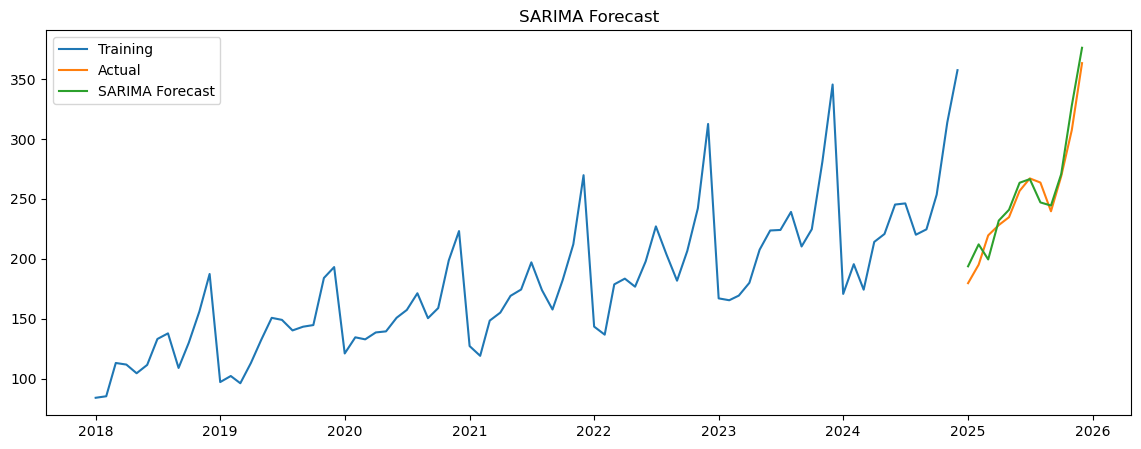

In [19]:
forecast_sarima = model_fit.forecast(steps=12)
plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label="Training")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast_sarima, label="SARIMA Forecast")
plt.legend()
plt.title("SARIMA Forecast")

1. Yes, SARIMA should capture seasonality better than ARIMA because it includes seasonal terms.
2. Generally yes, if the forecast line follows the main rises and falls of the actual series.
3. Usually occur at sharp peaks or drops, especially where actual sales differ strongly from the expected seasonal pattern.

#### Exercise 22: Evaluate SARIMA

In [21]:
mae_sarima = mean_absolute_error(test, forecast_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test, forecast_sarima))
print("SARIMA MAE:", mae_sarima)
print("SARIMA RMSE:", rmse_sarima)

SARIMA MAE: 10.40696162221032
SARIMA RMSE: 12.49149710016287


#### Exercise 23: Compare ARIMA and SARIMA

In [22]:
comparison = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA"],
    "MAE": [mae, mae_sarima],
    "RMSE": [rmse, rmse_sarima]
})
print(comparison)

    Model        MAE       RMSE
0   ARIMA  43.204813  57.548983
1  SARIMA  10.406962  12.491497


1. Lower MAE: SARIMA
2. Lower RMSE: SARIMA
3. SARIMA, because it explicitly models seasonal patterns.
4. the data has seasonality, which SARIMA can model while ARIMA cannot.
5. No. A more complex model can overfit and perform worse.
6. ARIMA would likely perform similarly or better, and SARIMA's seasonal component would provide little/no benefit.

### Part 12: Model Experimentation

#### Exercise 24: Try Different ARIMA Models

In [23]:
models = {
    "ARIMA(0,1,1)": (0, 1, 1),
    "ARIMA(1,1,0)": (1, 1, 0),
    "ARIMA(1,1,1)": (1, 1, 1),
    "ARIMA(2,1,1)": (2, 1, 1),
    "ARIMA(1,1,2)": (1, 1, 2),
    "ARIMA(2,1,2)": (2, 1, 2)
}

results = []

for name, order in models.items():
    model = ARIMA(train, order=order)
    fitted = model.fit()

    forecast = fitted.forecast(steps=12)

    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))

    results.append([name, mae, rmse])

comparison = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE"]
)

comparison

C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  

,Model,MAE,RMSE
0,"ARIMA(0,1,1)",51.953995,59.472534
1,"ARIMA(1,1,0)",101.221211,109.801149
2,"ARIMA(1,1,1)",43.204813,57.548983
3,"ARIMA(2,1,1)",38.362368,51.464310
4,"ARIMA(1,1,2)",41.117597,55.215140
5,"ARIMA(2,1,2)",28.415114,42.051494


#### Exercise 25: Try Different SARIMA Models

In [24]:
models = {
    "SARIMA 1": ((1,1,1), (1,1,1,12)),
    "SARIMA 2": ((0,1,1), (1,1,1,12)),
    "SARIMA 3": ((1,1,0), (1,1,1,12)),
    "SARIMA 4": ((1,1,1), (0,1,1,12))
}

results = []

for name, (order, seasonal_order) in models.items():

    model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order
    )

    fitted = model.fit(disp=False)

    forecast = fitted.forecast(steps=12)

    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    aic = fitted.aic

    results.append([name, aic, mae, rmse])

comparison = pd.DataFrame(
    results,
    columns=["Model", "AIC", "MAE", "RMSE"]
)

comparison

C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  

,Model,AIC,MAE,RMSE
0,SARIMA 1,591.124036,10.406962,12.491497
1,SARIMA 2,589.387273,10.614014,12.664037
2,SARIMA 3,616.101481,15.306270,16.776722
3,SARIMA 4,589.217115,10.589405,12.693662


1. Lowest AIC: SARIMA 4
2. Lowest MAE: SARIMA 1
3. Lowest RMSE: SARIMA 1
4. No. SARIMA 4 has the lowest AIC, while SARIMA 1 has the lowest MAE and RMSE.
5. SARIMA 1, because it has the lowest MAE and RMSE, meaning it gives the best forecasting accuracy.

### Part 13: Final Forecasting Challenge

#### Exercise 26: Train the Best Model on All Historical Data

In [26]:
final_model = SARIMAX(
    df["sales"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)

final_fit = final_model.fit(disp=False)

C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Abity\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### Exercise 27: Forecast the Next 12 Months

In [27]:
future_forecast = final_fit.forecast(steps=12)
future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)
future = pd.DataFrame({
    "date": future_dates,
    "forecast_sales": future_forecast
})
print(future)

                 date  forecast_sales
2026-01-01 2026-01-01      204.155005
2026-02-01 2026-02-01      218.603277
2026-03-01 2026-03-01      233.955797
2026-04-01 2026-04-01      247.789988
2026-05-01 2026-05-01      255.732404
2026-06-01 2026-06-01      276.945812
2026-07-01 2026-07-01      285.964652
2026-08-01 2026-08-01      279.129895
2026-09-01 2026-09-01      260.027205
2026-10-01 2026-10-01      287.142626
2026-11-01 2026-11-01      330.478726
2026-12-01 2026-12-01      384.929174


#### Exercise 28: Plot the Final Forecast

Text(0.5, 1.0, '12-Month Sales Forecast')

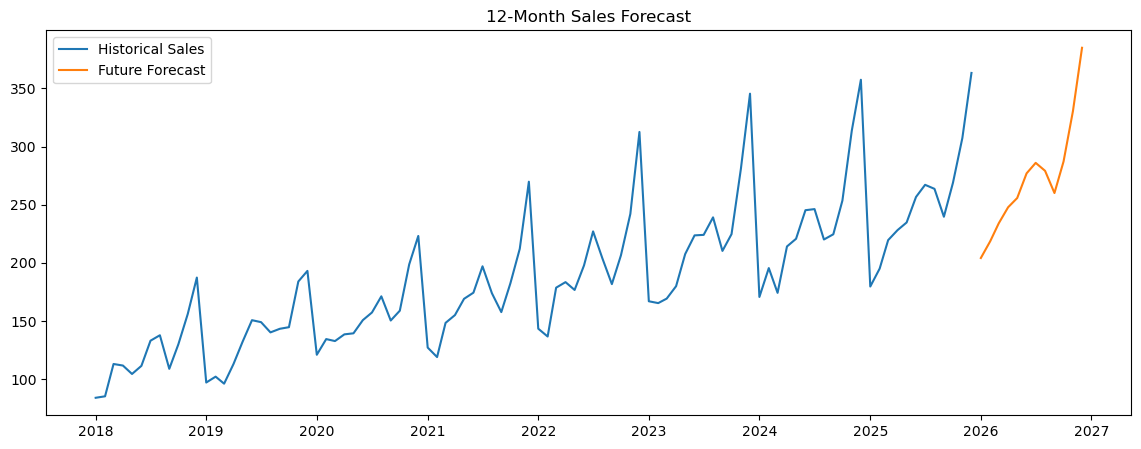

In [28]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["sales"], label="Historical Sales")
plt.plot(future["date"], future["forecast_sales"], label="Future Forecast")
plt.legend()
plt.title("12-Month Sales Forecast")

1. see from above.
2. December — 384.93
3. January — 204.16
4. Yes. Sales generally rise through the year, with a dip around August–September, then a strong increase toward November–December.
5. Yes, if your historical data shows higher sales toward the end of the year. The forecast shows a reasonable seasonal pattern rather than random fluctuations.

### Part 14: Final Analysis & Synthesis

#### Exercise 29: Write Your Conclusions

1. Decomposition
    * a. The sales series showed an overall upward trend.
    * b. A yearly seasonal pattern was observed, with stronger sales toward the end of the year.
    * c. Multiplicative decomposition was more appropriate because seasonal variation changed with the level of the series.
    * d. The size of seasonal fluctuations increased as sales increased.
2. Moving Average
    * a. The average of observations within a fixed window, used to smooth a time series.
    * b. Produces more smoothing but removes more short-term variation.
    * c. Larger windows are smoother but less responsive; smaller windows are more responsive but noisier.
    * d. The 12-month moving average was most useful for understanding the long-term trend and yearly seasonality.
3. Stationarity
* a. Not stationary.
* b. The ADF test failed to reject the unit-root null hypothesis.
* c. Differencing removed the trend and made the series stationary.
* d. d = 1.
4. ADF
* a. H₀: The series has a unit root / is non-stationary.
* b. p < 0.05: Reject H₀, series is likely stationary.
* c. p > 0.05: Fail to reject H₀, series is likely non-stationary.
* d. Before differencing: Failed to reject H₀, non-stationary.
* e. After differencing: Rejected H₀, stationary.
5. ACF and PACF
* a. ACF Measures correlation between a series and its past values at different lags.
* b. PACF Measures the direct correlation at a lag after removing effects of intermediate lags.
* c. ACF includes indirect relationships; PACF isolates the direct relationship.
* d. The ACF pattern suggested the MA component (q).
* e. The PACF pattern suggested the AR component (p).
* f. Yes, supporting the use of SARIMA.
6. ARIMA
* a. p: Number of autoregressive terms.
* b. d: Number of times the series is differenced.
* c. q: Number of moving-average terms.
* d. Best ARIMA: The best model was the candidate with the lowest forecasting error based on the comparison.
7. SARIMA
* a. It extends ARIMA to explicitly model seasonality.
* b.
    * P: Seasonal AR terms.
    * D: Seasonal differencing.
    * d. Q: Seasonal MA terms.
* c. s = 12: Represents 12-month yearly seasonality.
* d. Yes. SARIMA had much lower error: MAE = 10.41, RMSE = 12.49, compared with ARIMA's MAE = 43.20, RMSE = 57.55.
8. Final Forecast
* a. SARIMA(1,1,1)(1,1,1,12).
* b. It produced the lowest MAE and RMSE, giving the best forecasting accuracy.
* c.
    * Jan: 204.16
    * Feb: 218.60
    * Mar: 233.96
    * Apr: 247.79
    * May: 255.73
    * Jun: 276.95
    * Jul: 285.96
    * Aug: 279.13
    * Sep: 260.03
    * Oct: 287.14
    * Nov: 330.48
    * Dec: 384.93
* d. Business decisions: The forecasts can help with inventory planning, staffing, budgeting, production, and preparing for high-demand months, especially November and December.